In [1]:
import os
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import sympy as sp
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
RUN_ID = '1205_cook'
DT = 1
Q0 = 17921.57581 
SAVE  = False
ITS = int(1e1)

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  0.01,
    's':  0.001,
    'sdot': 0.001
    }


VARIABLES = ['R0', 'R1', 'C1','k','s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"

In [2]:
model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
#model_name = '0510_2034_combo_low_c_d_combo_V-dynamic_F-dynamic_702.38min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    print('Predicting k with NN')
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)



df = Param_symbol.read_raw_data('combo_half')
trajs = prepare_data(df)

data = data_param(BAT_MODEL, trajs)
display(data)

# diff_vals = data.max(axis=0) - data.min(axis=0)
# print(diff_vals)

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k,s,sdot
0,0,0.58,25.6,2.887365,-3.679552,1.000000,0.009722,1695.354614,0.007000,0.031640,0.000000,0.000045
1,0,0.58,25.6,2.887365,-3.679552,0.999839,0.009722,1695.666748,0.007000,0.031640,0.000045,0.000045
2,0,0.58,25.6,2.887365,-3.679552,0.999678,0.009722,1695.979370,0.007000,0.031640,0.000090,0.000045
3,0,0.58,25.6,2.887365,-3.679552,0.999517,0.009723,1696.292358,0.007000,0.031640,0.000134,0.000045
4,0,0.58,25.6,2.887365,-3.679552,0.999356,0.009723,1696.605591,0.007000,0.031641,0.000179,0.000045
...,...,...,...,...,...,...,...,...,...,...,...,...
241513,106,5.00,0.0,24.891078,0.000000,0.233333,0.192620,4690.878418,0.009318,0.023301,0.291108,0.000541
241514,106,5.00,0.0,24.891078,0.000000,0.231944,0.192629,4627.829590,0.009670,0.023302,0.291649,0.000541
241515,106,5.00,0.0,24.891078,0.000000,0.230556,0.192637,4564.943359,0.010054,0.023303,0.292190,0.000541
241516,106,5.00,0.0,24.891078,0.000000,0.229167,0.192645,4502.242188,0.010466,0.023304,0.292731,0.000541


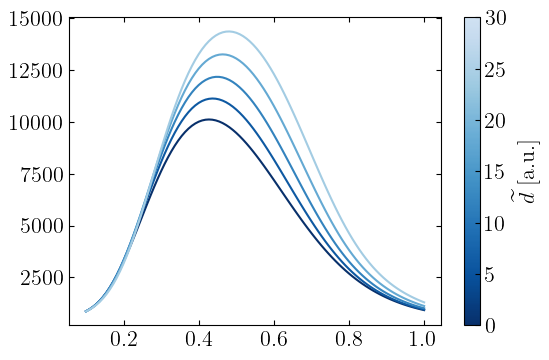

In [ ]:
u_per_vals = np.linspace(0,30,5)
C_rates_vals = np.array([0.5, 1, 2, 3, 4, 5])
soc = np.linspace(0.1,1,100)

C = 5
#for C in C_rates_vals:
import matplotlib.colors as mpl_colors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap

norm = Normalize(vmin=C_rates_vals.min(), vmax=C_rates_vals.max())
norm_u = Normalize(vmin=0, vmax=30)

fig,ax = plt.subplots(figsize=(6,4))
base = plt.cm.Blues_r
Blues_cut = LinearSegmentedColormap.from_list(
        "Blues_custom", base(np.linspace(0.0, 0.8, 256)))
cmap = Blues_cut

# base = plt.cm.Reds_r
# Reds_cut = LinearSegmentedColormap.from_list(
#         "Reds_custom", base(np.linspace(0.0, 0.8, 256)))
# cmap_r = Reds_cut

for n,u in enumerate(u_per_vals):
    C1_vals = C1_nn(C, u, soc) 
    ax.plot(soc, C1_vals, color=cmap(n/len(u_per_vals)), label=f'u={u:.1f}%')

sm = ScalarMappable(cmap=cmap, norm=norm_u)
fig.colorbar(sm, ax=ax, label=r'$\widetilde{d}$ [a.u.]')


In [ ]:
# import matplotlib.colors as mpl_colors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap


def plot_element_sweep(model, element, sweep = 'u_per', fixed = 1, sweep_vals = None):
    ''' If sweep 'u_per', then fixed_value is 'C_rate', and vice versa. '''

    if sweep_vals is None:
        if sweep == 'u_per':
            sweep_vals = np.linspace(0,30,5)
        else:
            sweep_vals = np.array([0.5, 1, 2, 3, 4, 5])

    soc = np.linspace(1,0,100)

    if sweep == 'u_per':
        bar_label  = r'$\widetilde{d}$ [%]'
        fixed_tag    = fr'$C = {fixed:g}$'
    elif sweep == 'C_rate':
        bar_label  = 'C-rate [a.u.]'
        fixed_tag    = fr'$\widetilde{{d}} = {fixed:g}\%$'

    norm = Normalize(vmin=C_rates_vals.min(), vmax=C_rates_vals.max())
    norm_u = Normalize(vmin=0, vmax=30)

    fig,ax = plt.subplots(figsize=(6,4))
    base = plt.cm.Blues_r
    Blues_cut = LinearSegmentedColormap.from_list(
            "Blues_custom", base(np.linspace(0.0, 0.8, 256)))
    cmap = Blues_cut

    # base = plt.cm.Reds_r
    # Reds_cut = LinearSegmentedColormap.from_list(
    #         "Reds_custom", base(np.linspace(0.0, 0.8, 256)))
    # cmap_r = Reds_cut



    for n,u in enumerate(u_per_vals):
        C1_vals = C1_nn(C, u, soc) 
        ax.plot(soc, C1_vals, color=cmap(n/len(u_per_vals)), label=f'u={u:.1f}%')

    sm = ScalarMappable(cmap=cmap, norm=norm_u)
    fig.colorbar(sm, ax=ax, label=r'$\widetilde{d}$ [a.u.]')

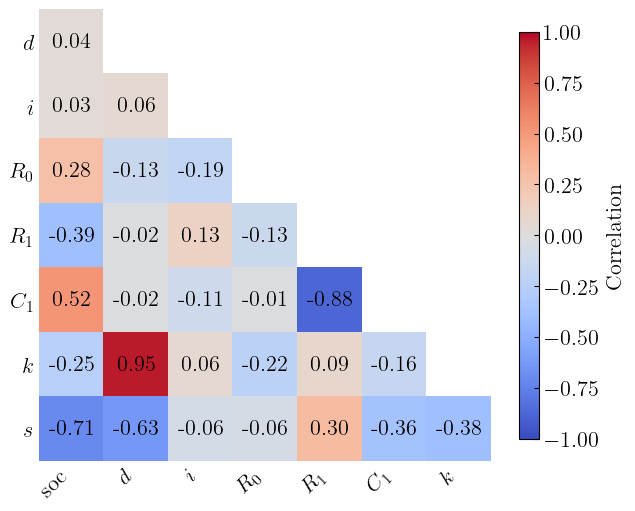

In [61]:
# X = data[['soc','u','I','R0','R1','C1','k','s']].values
# feature_names = ['soc','u','I','R0','R1','C1','k','s']
# with np.errstate(invalid="ignore", divide="ignore"):
#     corr = np.corrcoef(X, rowvar=False)


# fig, ax_corr = plt.subplots(figsize=(7, 5))
# im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# ax_corr.set_xticks(np.arange(len(feature_names)))
# ax_corr.set_yticks(np.arange(len(feature_names)))
# ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
# ax_corr.set_yticklabels(feature_names)
# ax_corr.set_title("Correlation matrix")

# for i in range(corr.shape[0]):
#     for j in range(corr.shape[1]):
#         ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

# fig.colorbar(im, ax=ax_corr, label="Correlation")
# plt.tight_layout()
# plt.show()

X = data[['soc','u_per','C','R0','R1','C1','k','s']].values
feature_names = ['soc', r'$d$', r'$i$', r'$R_0$', r'$R_1$', r'$C_1$', r'$k$', r'$s$']

with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)

# Keep strictly lower triangle (no diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
corr_masked = np.where(mask, np.nan, corr)

# Drop the now-empty first column and last row
corr_trim = corr_masked[1:, :-1]
row_labels = feature_names[1:]
col_labels = feature_names[:-1]

cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color="white")

fig, ax_corr = plt.subplots(figsize=(7, 5), constrained_layout=True)
im = ax_corr.imshow(corr_trim, cmap=cmap, vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(col_labels)))
ax_corr.set_yticks(np.arange(len(row_labels)))
ax_corr.set_xticklabels(col_labels, rotation=45, ha="right")
ax_corr.set_yticklabels(row_labels)
# ax_corr.set_title("Correlation matrix")

for i in range(corr_trim.shape[0]):
    for j in range(corr_trim.shape[1]):
        if not np.isnan(corr_trim[i, j]):
            ax_corr.text(j, i, f"{corr_trim[i, j]:.2f}",
                         ha="center", va="center", color="black")

# Kill the spines
for s in ax_corr.spines.values():
    s.set_visible(False)
ax_corr.tick_params(length=0)  # also remove tick marks

fig.colorbar(im, ax=ax_corr, label="Correlation", shrink=0.9)
#plt.savefig(f'element_corr_matrix.pdf')

In [55]:
df_CC = Param_symbol.read_raw_data('merged_DC_hyper')
df_CC = Param_symbol.read_raw_data('merged_pulse_hyper')
display(df_CC)

,u_par,C,t,V,F,u,Ue,soc,I,trajectory,eta
0,19.1,4.5,0,4.229418,0.078557,-2.745291,4.324996,0.999999,11.200985,0,0.095578
1,19.1,4.5,1,4.118165,0.078575,-2.745291,4.321218,0.998758,22.401970,0,0.203053
2,19.1,4.5,2,4.099471,0.078591,-2.745291,4.317412,0.997508,22.401970,0,0.217940
3,19.1,4.5,3,4.084324,0.078608,-2.745291,4.313605,0.996258,22.401970,0,0.229282
4,19.1,4.5,4,4.071481,0.078625,-2.745291,4.309799,0.995008,22.401970,0,0.238318
...,...,...,...,...,...,...,...,...,...,...,...
227346,17.2,2.5,2723,2.619369,0.080803,-2.472199,3.381726,0.096906,12.445539,74,0.762358
227347,17.2,2.5,2724,2.579749,0.080813,-2.472199,3.379533,0.096211,12.445539,74,0.799784
227348,17.2,2.5,2725,2.532106,0.080822,-2.472199,3.377339,0.095517,12.445539,74,0.845233
227349,17.2,2.5,2726,2.478750,0.080832,-2.472199,3.375146,0.094822,12.445539,74,0.896395


In [56]:
# Extract expressions from symbolic regression results
def extract_expressions(run_id):
    # Load the symbolic regression results
    elements = ['k', 'R1', 'C1', 'R0', 's']
    
    expressions = {}

    for elem in elements:
    
        results_path = Path(f'sr_models/model_{elem}_{run_id}.csv')
        if not results_path.exists():
            raise FileNotFoundError(f"Results file not found: {results_path}")
    
        results_df = pd.read_csv(results_path)

        expr = results_df['sympy_format']# == int(results_df['complexity'].mean())]
        expressions[elem] = expr

    
    return expressions

print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")
#res, R0_expr, R1_expr, C1_expr, k_expr, s_expr = extract_expressions(RUN_ID)
expressions = extract_expressions(RUN_ID)
R0_expr = expressions['R0']
R1_expr = expressions['R1']
C1_expr = expressions['C1']
k_expr = expressions['k']
s_expr = expressions['s']

latent_variables = {'x0': 'c-rate', 'x1': 'd_per', 'x2': 'soc', 'x3':'s'}


from collections import Counter

symbol_counts = {}
for elem in VARIABLES:
    counter = Counter()
    for expr in expressions[elem]:
        sympy_expr = sp.sympify(expr)

        counter.update(map(str, sympy_expr.free_symbols))

    symbol_counts[elem] = counter

# convert to dataframe for better visualization
symbol_counts_df = pd.DataFrame(symbol_counts).fillna(0).astype(int)

for elem in symbol_counts_df:
    symbol_counts_df[elem] = 100 * symbol_counts_df[elem] / expressions[elem].shape[0]

df_symcounts = symbol_counts_df.transpose()
display(df_symcounts)
print(f'Latent variables: {latent_variables}')
df_symcounts.columns = [latent_variables.get(col, col) for col in df_symcounts.columns]
display(df_symcounts)

# round values to 1 decimal place
df_symcounts = df_symcounts.round(1)

def df_latex_table(df, caption=None, label=None):
    latex_str = df.to_latex(index=True, escape=False)
    if caption:
        latex_str = latex_str.replace('\\begin{tabular}', f'\\begin{{table}}[ht]\n\\centering\n\\caption{{{caption}}}\n\\begin{{tabular}}')
    if label:
        latex_str = latex_str.replace('\\end{tabular}', f'\\end{{tabular}}\n\\label{{{label}}}\n\\end{{table}}')
    return latex_str

latex_table = df_latex_table(df_symcounts, caption="Symbol usage percentages in SR expressions", label="tab:symbol_usage")
print(latex_table)


Loading symbolic regression results for RUN_ID: 1205_cook


,x2,x0,x1,x3
R0,93.750000,81.25000,0.00,0.00
R1,95.238095,90.47619,0.00,0.00
C1,93.750000,37.50000,25.00,0.00
k,87.500000,0.00000,93.75,0.00
s,68.750000,93.75000,81.25,6.25


Latent variables: {'x0': 'c-rate', 'x1': 'd_per', 'x2': 'soc', 'x3': 's'}


,soc,c-rate,d_per,s
R0,93.750000,81.25000,0.00,0.00
R1,95.238095,90.47619,0.00,0.00
C1,93.750000,37.50000,25.00,0.00
k,87.500000,0.00000,93.75,0.00
s,68.750000,93.75000,81.25,6.25


\begin{table}[ht]
\centering
\caption{Symbol usage percentages in SR expressions}
\begin{tabular}{lrrrr}
\toprule
 & soc & c-rate & d_per & s \\
\midrule
R0 & 93.800000 & 81.200000 & 0.000000 & 0.000000 \\
R1 & 95.200000 & 90.500000 & 0.000000 & 0.000000 \\
C1 & 93.800000 & 37.500000 & 25.000000 & 0.000000 \\
k & 87.500000 & 0.000000 & 93.800000 & 0.000000 \\
s & 68.800000 & 93.800000 & 81.200000 & 6.200000 \\
\bottomrule
\end{tabular}
\label{tab:symbol_usage}
\end{table}



In [57]:
def display_expresions(elem, latent_variables, expressions = expressions, complexity = None):

    print(f"\nExpression for {elem}:")
    for j,expr in enumerate(expressions[elem]):
        sympy_expr = sp.sympify(expr)
        if complexity is not None:
            display(Math(f"\\Large {complexity[j]}: {elem} = {sp.latex( sympy_expr)}"))
        else:
            display(Math(f"\\Large {j}: {elem} = {sp.latex(sympy_expr)}"))

sr_models/model_k_1305_hSOC.csv


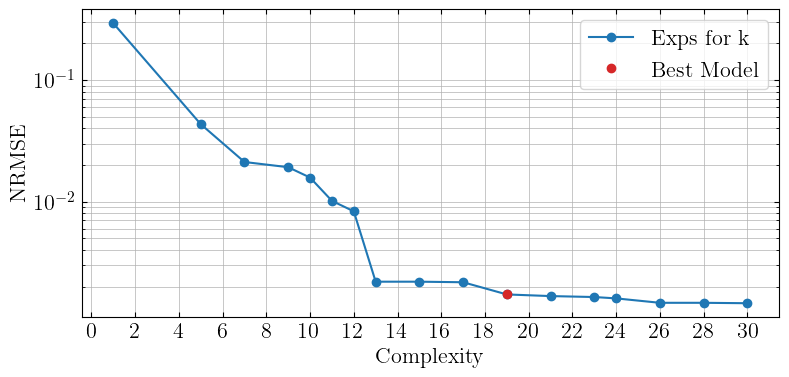


Expression for k:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [59]:
RUN_ID = '1305_hSOC'
elem = 'k'
#Param_symbol.post_pareto_plot(elem,run_id=RUN_ID)
df = pd.read_csv(f'sr_models/model_{elem}_{RUN_ID}.csv')

complexity = df['complexity'].values


def post_pareto_plot(elem, run_id, colors = COLORS, diff = diff_vals, ref_values = REF_VALUES):
    print(f'sr_models/model_{elem}_{run_id}.csv')
    df_model = pd.read_csv(f'sr_models/model_{elem}_{run_id}.csv')
    best = pd.read_csv(f'sr_models/model_{elem}_best_{run_id}.csv')
    best_complexity = float(best.iloc[0, 0])
    best_rows = df_model[np.isclose(df_model['complexity'], best_complexity)]
    best_ind = int(best.iloc[0,0])
    plt.figure(figsize=(9, 4))
    plt.xticks(np.arange(0, df_model['complexity'].max() + 1, 2))
    plt.grid(True, which="both", ls="-", linewidth=0.5)
    plt.plot(df_model['complexity'], np.sqrt(df_model['loss']) * ref_values[elem] / diff[elem], marker='o', linestyle='-', color=colors[0], label=f'Exps for {elem}')
    plt.plot(best_rows['complexity'], np.sqrt(best_rows['loss']) * ref_values[elem] / diff[elem], marker='o', linestyle='', color=colors[1], label='Best Model')
    plt.xlabel('Complexity')
    plt.ylabel('NRMSE')
    plt.yscale('log')
    plt.legend()
    plt.show()


post_pareto_plot(elem, RUN_ID)

display_expresions(elem, latent_variables, complexity= complexity)


#best_SR = {'R0': , 'R1': , 'C1': 15, 'k': , 's': }

In [48]:

R0_func = sp.lambdify(('x0', 'x1', 'x2'), R0_expr, 'numpy')
s_func = sp.lambdify(('x0', 'x1', 'x2','x3'), s_expr, 'numpy')
k_func = sp.lambdify(('x0', 'x1', 'x2'), k_expr, 'numpy')
R1_func = sp.lambdify(('x0', 'x1', 'x2'), R1_expr, 'numpy')
C1_func = sp.lambdify(('x0', 'x1', 'x2'), C1_expr, 'numpy')

# print("R0 expression variables:", R0_expr.free_symbols)
# print("s expression variables:", s_expr.free_symbols)
# print("k expression variables:", k_expr.free_symbols)
# print("R1 expression variables:", R1_expr.free_symbols)
# print("C1 expression variables:", C1_expr.free_symbols)

NotImplementedError: unhandled type: <class 'pandas.core.series.Series'>, 0                                     0.707502100000000
1                           0.68200666 + 0.008584766/x2
2                     0.6988391 + 0.00044620436/(x2**2)
3           3.38340600005804e-5*x0**3/x2**3 + 0.6918678
4          5.75628224745136e-13*x0**9/x2**9 + 0.6988973
5       (x0*0.06369303/x2 - 0.45800522)**6 + 0.69811314
6     sqrt((0.000127957503025289*x0**3/x2**3 - 0.225...
7     log((0.06473714*x0/x2 - 0.33497283)**9 + 2.012...
8     sin(0.000119966688527371*x0**3/x2**3)**6 + 0.6...
9           log((0.048480228*x0/x2)**(6*x0) + 2.010992)
10     sin((x0*0.047267273/x2)**(3*x0))**3 + 0.69903326
11    (sin((x0*0.048511166/x2)**(3*x0)) - 0.07365957...
12    (sin((x0*(0.0043465677 + 0.04773005/x2))**(3*x...
13    (sin((-0.24784903*x0/(x2*(x2 - 5.271073)))**(3...
14    (sin((-0.10491121*(x0/(x2 - 2.3637102) - 0.028...
15    (sin((-0.10507838*(x0/(x2 - 2.3766942) - 0.072...
dtype: object

# Importing data

In [ ]:
N_TRAJS = len(data['trajectory'].unique())
print(f'Number of trajectories: {N_TRAJS}')

Number of trajectories: 125


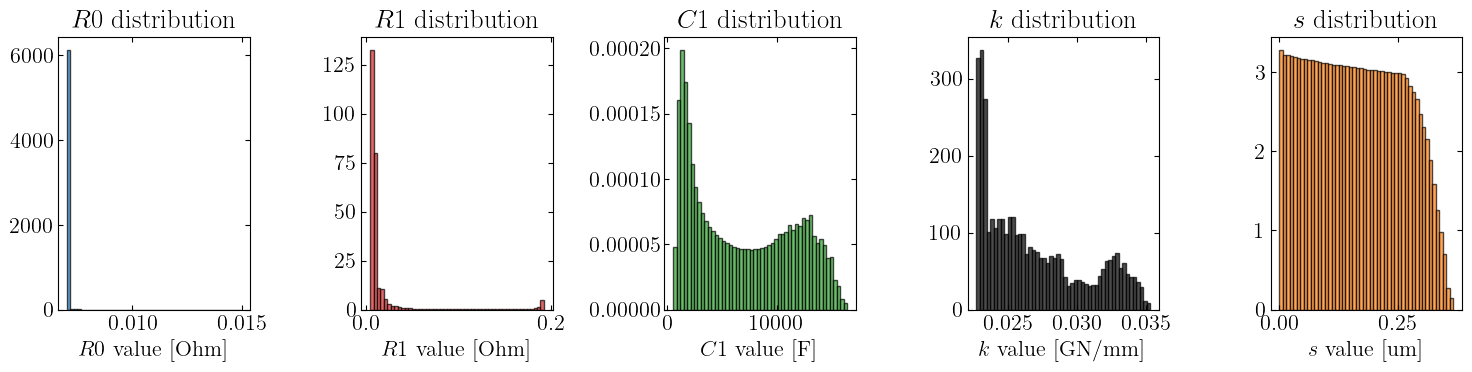

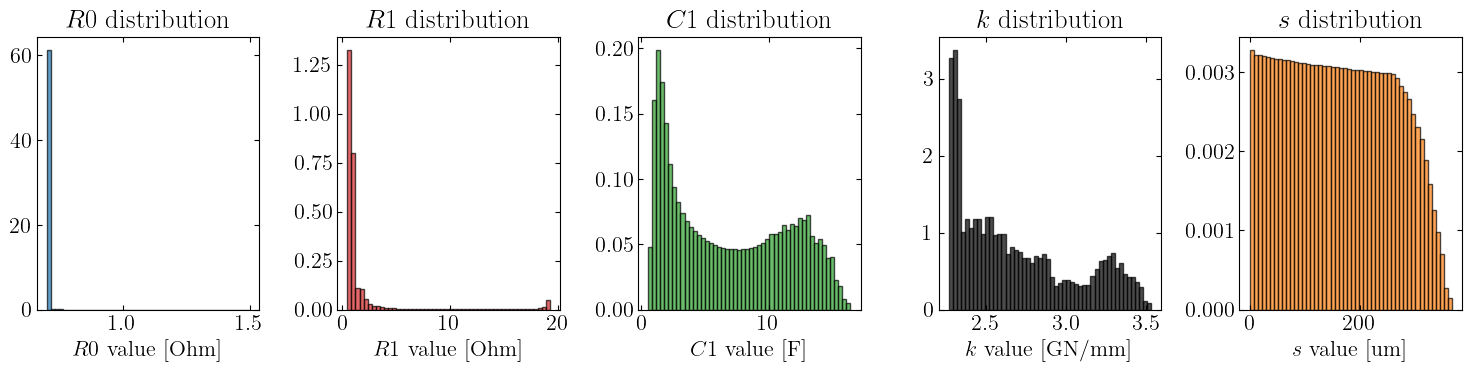

In [ ]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [ ]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 5e4:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values / REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values / REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values / REF_VALUES['C1']
    Y_k  = d_frame['k'].values  / REF_VALUES['k']
    try:
        Y_s = d_frame['sdot'].values  / REF_VALUES['s']
        X_s = d_frame[['C', 'u_per', 'soc', 's']].values
        X_s[:,-1]/= REF_VALUES['s']
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)

    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds],Y_R0[inds], Y_R1[inds], Y_C1[inds], Y_k[inds], Y_s[inds], X_s[inds]

In [ ]:
split_train = int(data['trajectory'].max() * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:

    data_train  = data[data['trajectory'] <= split_train]
    data_test   = data[data['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)

X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


Using every 4th data point for symbolic regression, total points: 48455
Using every 1th data point for symbolic regression, total points: 15749


# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.0039349715
Equation: 0.70747626

Model 1: Complexity=5, Loss=0.0037902724
Equation: (x2 * -0.03738403) + 0.72646016

Model 2: Complexity=7, Loss=0.00366495
Equation: (x2 ^ -0.025415761) * 0.6862289

Model 3: Complexity=8, Loss=0.0030334177
Equation: exp(x2 * -33.140514) + 0.70326877

Model 4: Complexity=10, Loss=0.0026423174
Equation: exp((-47.881237 * x2) + x0) + 0.70326877



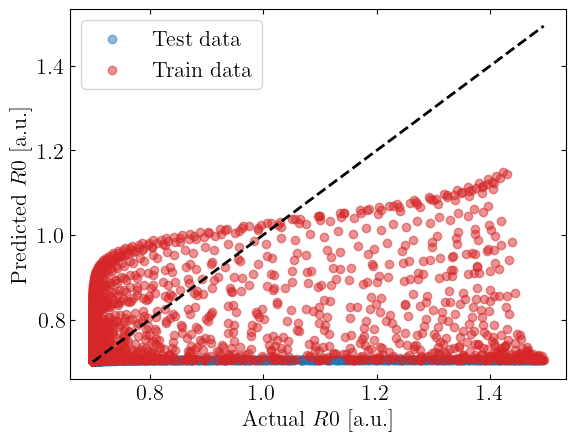

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: exp(x2*(-33.140514)) + 0.70326877
Loss: 0.0030334177
Best model complexity: 8


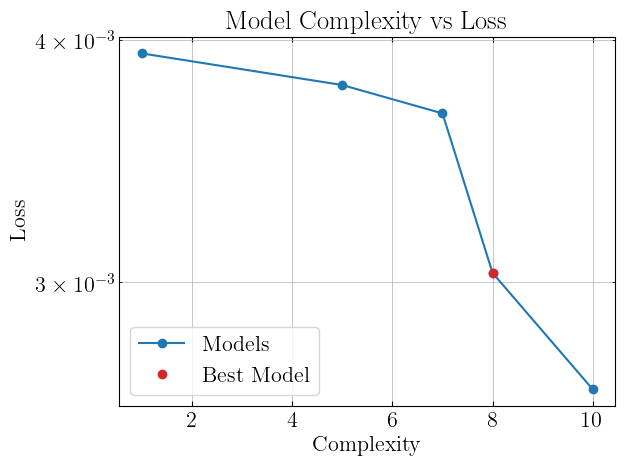

In [ ]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
Param_symbol.print_best_model(model_R0)
Param_symbol.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=10.8001585
Equation: 1.7113239

Model 1: Complexity=3, Loss=6.288519
Equation: 0.6179902 / x2

Model 2: Complexity=5, Loss=4.6025476
Equation: (x0 * 0.49635983) / x2

Model 3: Complexity=7, Loss=1.6615986
Equation: square((0.20508623 / x2) * x0)

Model 4: Complexity=14, Loss=1.6024269
Equation: exp((0.17798051 / (x2 / x0)) - tanh(0.61269575))

Model 5: Complexity=16, Loss=1.4611063
Equation: exp(log(exp(0.17798051 / (x2 / x0))) - 0.61269575)

Model 6: Complexity=20, Loss=1.3653466
Equation: square(exp(exp(log(2.0149555 / (x2 / x0)) - 3.259957)) + -0.38629344)

Model 7: Complexity=27, Loss=1.3290305
Equation: cube(log(log(exp(exp(((0.8091943 / (x2 / x0)) * 0.36321825) / 2.659617) + -0.106695265))) + 0.4153173)

Model 8: Complexity=29, Loss=1.0506302
Equation: cube(log(exp(log(exp(((1.012473 / (x2 / x0)) * 0.4941426) / 3.8028932) + -0.12972866)) + -0.12968272)) + 0.77113944



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: log(exp(0.131559319270339*x0/x2) - 0.25941138)**3 + 0.77113944
Loss: 1.0506302
Best model complexity: 29


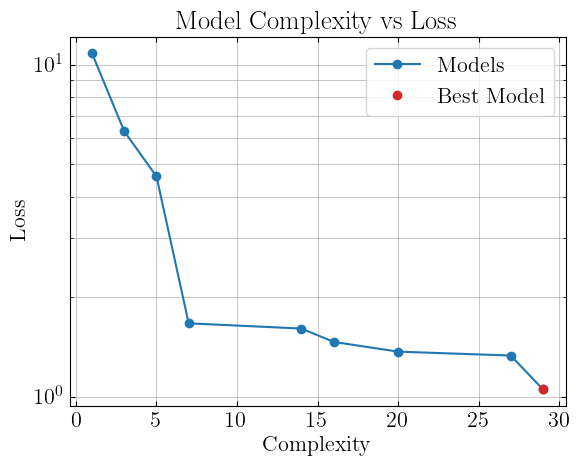

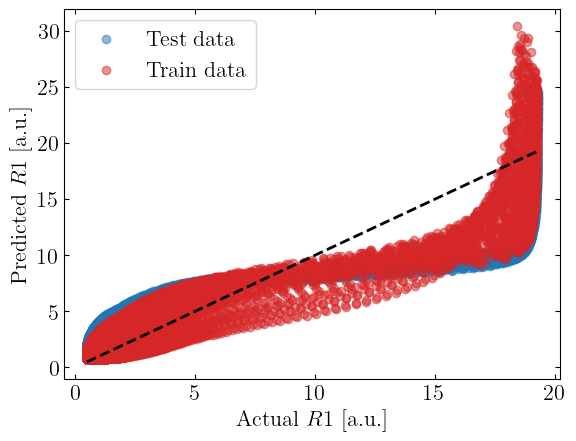

In [ ]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R1 = model_R1.equations_
Param_symbol.print_models(df_model_R1)
Param_symbol.print_best_model(model_R1)
Param_symbol.pareto_plot(model_R1)
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=21.865215
Equation: 6.8586416

Model 1: Complexity=3, Loss=20.79475
Equation: 7.3972144 - x2

Model 2: Complexity=5, Loss=17.436165
Equation: (1.4795473 - x2) * 7.060855

Model 3: Complexity=7, Loss=16.849392
Equation: cos(x2) * 8.864152

Model 4: Complexity=9, Loss=4.6355767
Equation: (square(1.0665898 - x2) * 63.992004) * x2

Model 5: Complexity=11, Loss=1.6987213
Equation: 14.055152 / cosh((0.41118538 - x2) / -0.15717275)

Model 6: Complexity=20, Loss=1.2334644
Equation: exp(((((x2 * x2) ^ -2.2940855) ^ x2) * 0.53650427) - (0.08881241 / x2))



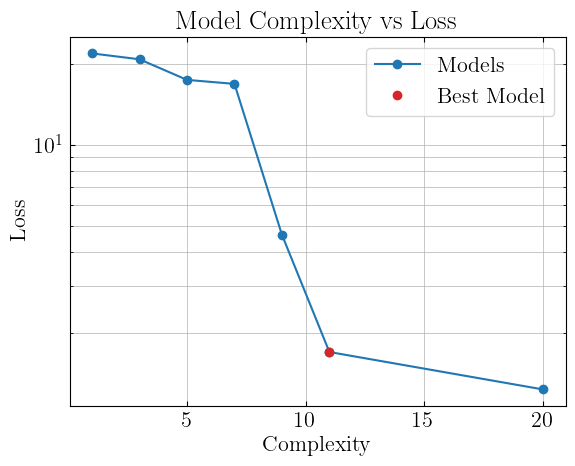

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 14.055152/cosh((0.41118538 - x2)/(-0.15717275))
Loss: 1.6987213
Best model complexity: 11


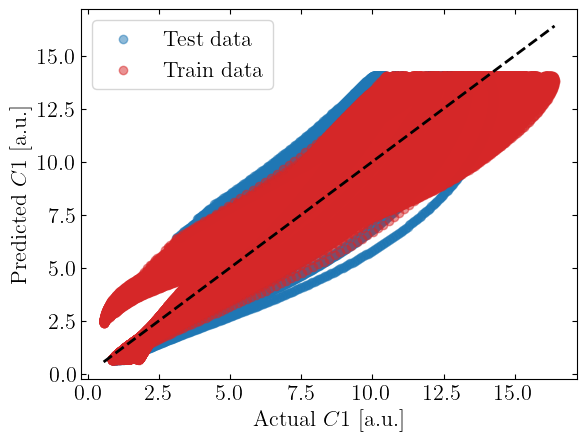

In [ ]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_C1 = model_C1.equations_
Param_symbol.print_models(df_model_C1)
Param_symbol.pareto_plot(model_C1)
Param_symbol.print_best_model(model_C1)
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.133298
Equation: 2.688178

Model 1: Complexity=5, Loss=0.0031988083
Equation: (x1 * 0.037463844) + 2.2488947

Model 2: Complexity=7, Loss=0.0030936813
Equation: ((x1 - x2) * 0.037463844) + 2.2488947

Model 3: Complexity=8, Loss=0.0010691609
Equation: exp(x1 * 0.025787191) + 1.2924892

Model 4: Complexity=10, Loss=0.0008553525
Equation: exp(0.025791472 * (x1 - x2)) + 1.2939835

Model 5: Complexity=12, Loss=0.00019643128
Equation: exp((x1 - (x2 / 0.41540575)) * 0.026145145) + 1.3303353

Model 6: Complexity=21, Loss=0.00017810223
Equation: exp((x1 - log(sinh(x2 + x2) - -0.035926834)) * 0.025791472) + 1.2939835



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: exp((x1 - x2/0.41540575)*0.026145145) + 1.3303353
Loss: 0.00019643128
Best model complexity: 12


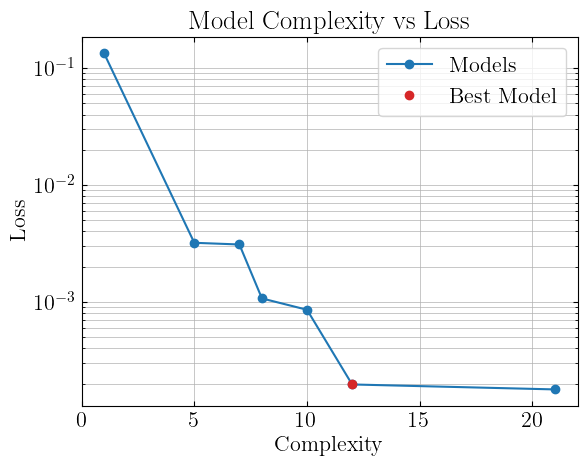

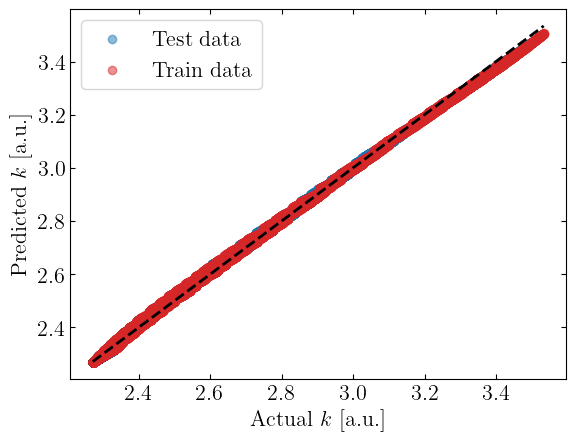

In [ ]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_k = model_k.equations_
Param_symbol.print_models(df_model_k)
Param_symbol.print_best_model(model_k)
Param_symbol.pareto_plot(model_k)
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(s,i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.009704462
Equation: 0.16605723

Model 1: Complexity=3, Loss=0.00012290681
Equation: x0 * 0.099736

Model 2: Complexity=5, Loss=0.00012290492
Equation: 0.094055526 / (0.9442146 / x0)

Model 3: Complexity=23, Loss=0.00012289845
Equation: log(log(exp(exp(exp((log(x0) + 1.0690753) - 3.3745112)))))

Model 4: Complexity=25, Loss=0.00012289351
Equation: log(cube(exp(tanh(exp(log(x0) - 3.1896214))) ^ 0.8105684))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: x0*0.099736
Loss: 0.00012290681
Best model complexity: 3


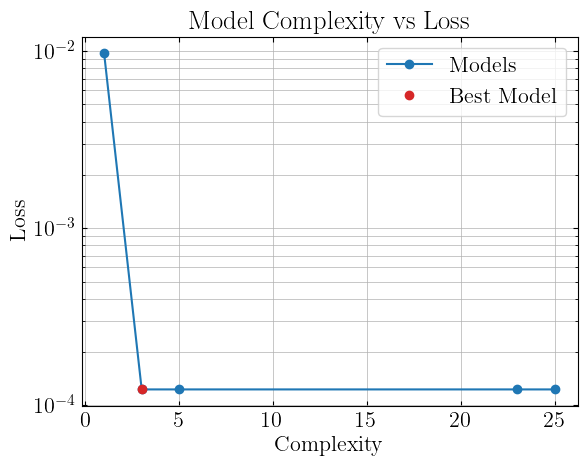

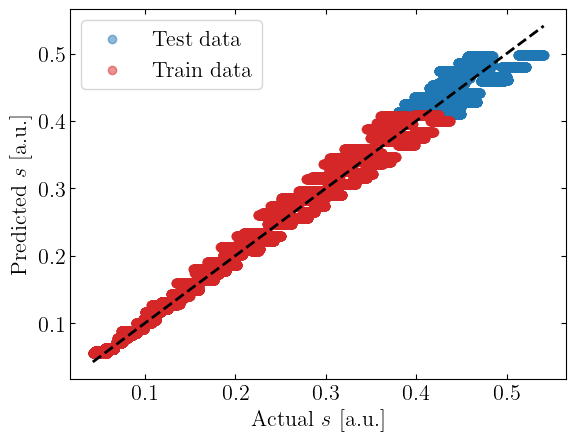

In [ ]:
import_reload()
model_s = Param_symbol.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_s = model_s.equations_
Param_symbol.print_models(df_model_s)
Param_symbol.print_best_model(model_s, s = True)
Param_symbol.pareto_plot(model_s)
Param_symbol.parity_plot('s',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

In [ ]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    's':  model_s
}

In [ ]:
def get_traj(trajectory_id, test = False):
    if test:
        traj = data_test[data_test['trajectory'] == trajectory_id + split_train]
    else:
        traj = data_train[data_train['trajectory'] == trajectory_id]
    return traj

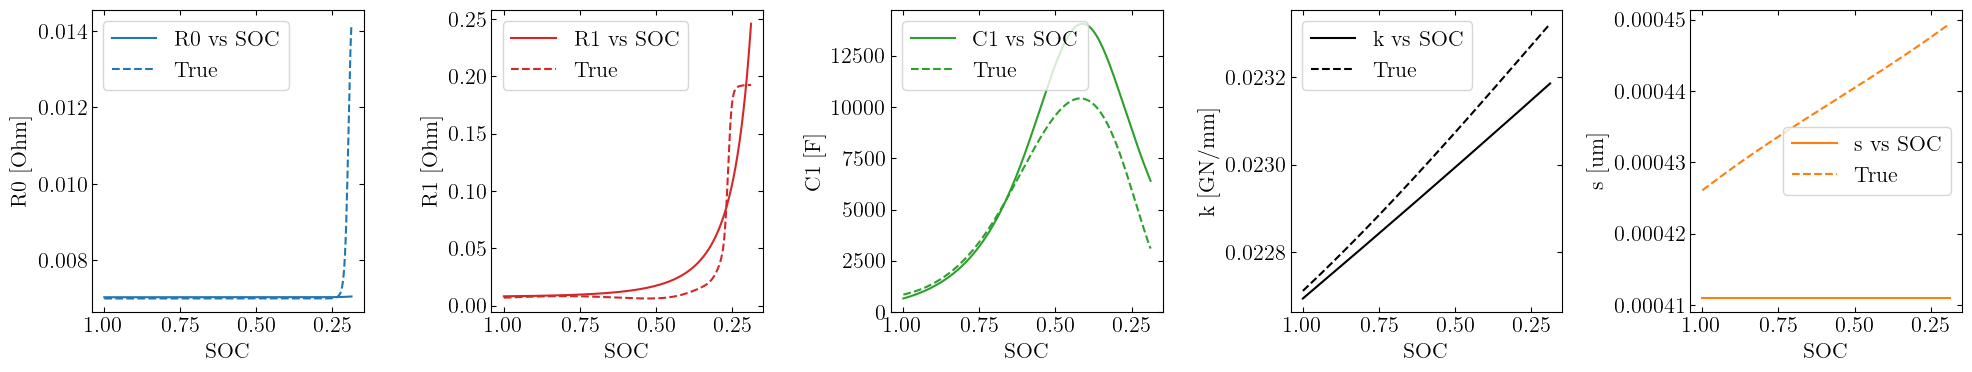

In [ ]:
def plot_soc(models, traj):
    C_fixed = traj['C']
    u_per_fixed = traj['u_per']
    soc = traj['soc'].values

    f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

    for var in VARIABLES:
        model = models[var]
        if var == 's':
            X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc, np.full_like(soc, REF_VALUES['s'])))
            Y_true = traj['sdot']
        else:
            X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
            Y_true = traj[var]
        Y_plot = model.predict(X_plot) * REF_VALUES[var]
        ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
        ax[VARIABLES.index(var)].set_xlabel('SOC')
        ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
        ax[VARIABLES.index(var)].legend()
        ax[VARIABLES.index(var)].invert_xaxis()
    plt.tight_layout()



traj = get_traj(trajectory_id = 1, test = True)
plot_soc(MODEL_DICT, traj)

ValueError: Length mismatch: Expected axis has 3 elements, new values have 4 elements

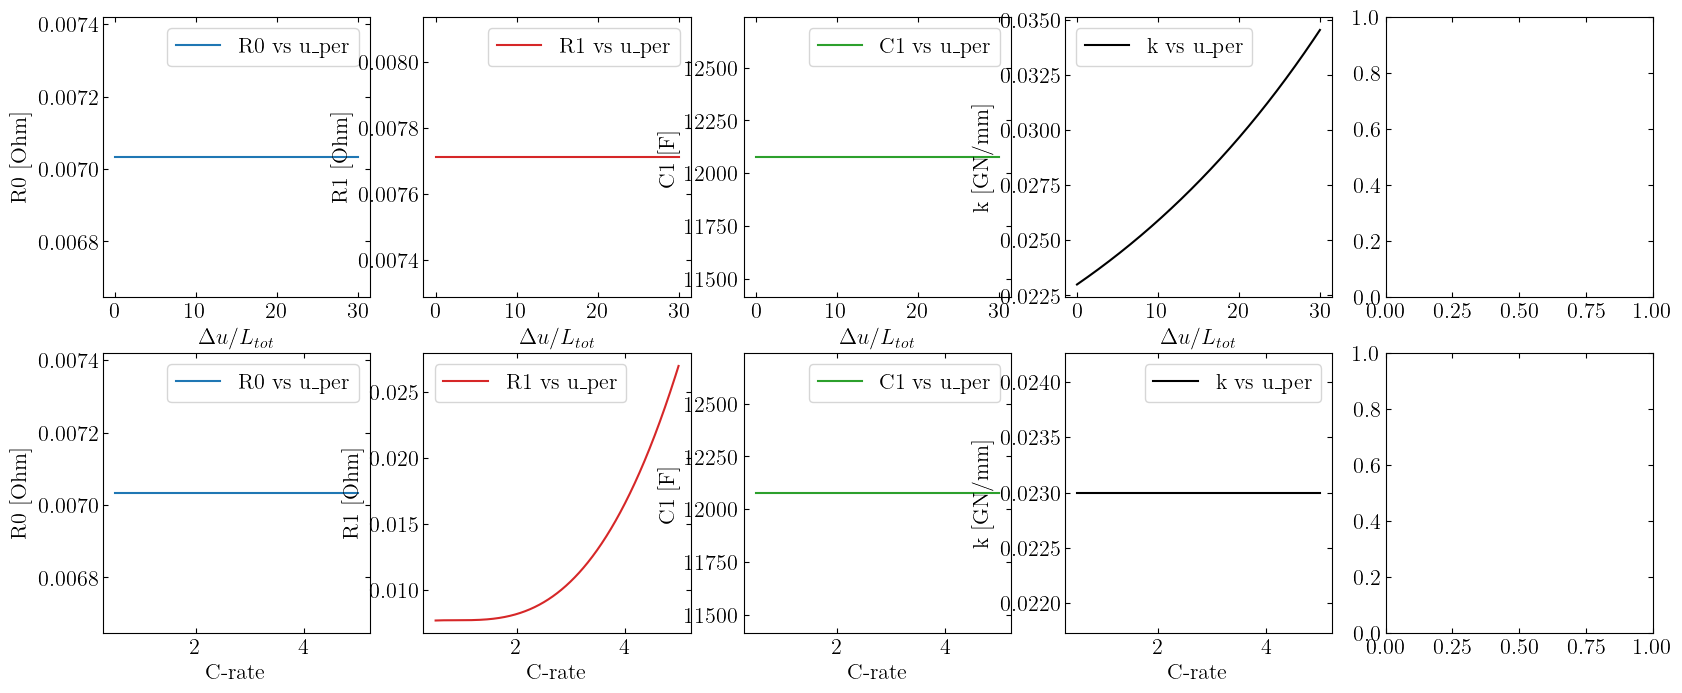

In [ ]:
def plot_d(models):
    u_per = np.linspace(0,30,1000)
    C_fixed = 1
    C = np.linspace(0.5,5,1000)
    u_fixed = 0
    soc_fixed = 0.5
    X_plot1 = np.column_stack((np.full_like(u_per, C_fixed), u_per, np.full_like(u_per, soc_fixed)))
    X_plot2 = np.column_stack((C, np.full_like(C, u_fixed), np.full_like(C, soc_fixed)))
    f, ax = plt.subplots(2, N_VAR, figsize=(4*N_VAR, N_VAR*8/5))

        
    for var in VARIABLES:
        model = models[var]
        Y_plot = model.predict(X_plot1) * REF_VALUES[var]
        ax[0,VARIABLES.index(var)].plot(u_per, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
        ax[0,VARIABLES.index(var)].set_xlabel(r'$\Delta u / L_{tot}$')
        ax[0,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[0,VARIABLES.index(var)].legend()
        Y_plot = model.predict(X_plot2) * REF_VALUES[var]
        ax[1,VARIABLES.index(var)].plot(C, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
        ax[1,VARIABLES.index(var)].set_xlabel(r'C-rate')
        ax[1,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[1,VARIABLES.index(var)].legend()
        
    plt.tight_layout()

plot_d(MODEL_DICT)


In [ ]:
if SAVE:
    Param_symbol.save_expressions(df_model_R0, f'R0_{RUN_ID}')
    Param_symbol.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_s, f's_{RUN_ID}')
    Param_symbol.save_expressions(model_s.get_best(), f's_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_k,  f'k_{RUN_ID}')
    Param_symbol.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_R1, f'R1_{RUN_ID}')
    Param_symbol.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_C1, f'C1_{RUN_ID}')
    Param_symbol.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')